### Model architecture in Equinox

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
from jax.experimental import sparse
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate
import time
jax.config.update("jax_enable_x64", True)
plt.style.use('seaborn-v0_8')


class ReservoirCell(eqx.Module):

    A: jax.Array
    B: jax.Array
    C: jax.Array
    Nr: int
    Nin: int
    alpha: int
    rho_sr: float
    rho_A: float
    sigma: float
    sigma_b: float

    def __init__(self, 
                 input_size: int, 
                 hidden_size=2000, 
                 sigma=0.084,
                 alpha=0.6,
                 rho_sr=0.8,
                 sigma_b=1.6,
                 rho_A=0.02, 
                 dtype=jnp.float64,
                 key=jax.random.key(2)):

        self.Nin = input_size
        self.Nr = hidden_size
        self.alpha = alpha
        self.rho_sr = rho_sr
        self.rho_A = rho_A
        self.sigma = sigma
        self.sigma_b = sigma_b
        
        key, split_key = jax.random.split(key)
        inc_indices = jax.random.choice(split_key, self.Nr * self.Nr, (int(self.Nr*self.Nr*self.rho_A),))
        A = jnp.zeros(self.Nr*self.Nr, dtype=jnp.float64)

        key, split_key = jax.random.split(split_key)
        vals = jax.random.uniform(split_key, int(self.Nr*self.Nr*self.rho_A), minval=-1, maxval=1, dtype=jnp.float64)
        A = A.at[inc_indices].set(vals)
        A = A.reshape(self.Nr, self.Nr)
        A = A*(self.rho_sr/jnp.max(jnp.abs(jnp.linalg.eigvals(A))))
        self.A = sparse.BCOO.fromdense(A)

        self.C = jnp.zeros((input_size, hidden_size), dtype=jnp.float64)

        key, split_key = jax.random.split(split_key)
        self.B = jax.random.uniform(split_key, (self.Nr, self.Nin), minval=-self.sigma, maxval=self.sigma, dtype=jnp.float64)
        
    @eqx.filter_jit
    def __call__(self, input, hidden):
        h_next = (1-self.alpha) * hidden + self.alpha * jnp.tanh(self.A @ hidden + self.B @ input + self.sigma_b * jnp.ones(self.Nr))
        return h_next


class ESN(eqx.Module):
    cell: ReservoirCell
    Nr: int

    def __init__(self, rescell, Nr):
        self.cell = rescell
        self.Nr = Nr
    
    @eqx.filter_jit
    def __call__(self, input_seq, init_state):
        def scan_fn(state, input):
            out1 = self.cell(input, state)
            return (out1, out1)
        final_state, seq_states = jax.lax.scan(scan_fn, init_state, input_seq)
        return seq_states
    
    @eqx.filter_jit
    def forecast(self, init_state, fcast_len):

        def scan_fn(state, _):
            out1 = self.cell(self.cell.C @ state, state)
            return (out1, self.cell.C @ out1)
        _, seq_states = jax.lax.scan(scan_fn, init_state, None, length=fcast_len)
        return seq_states

### Simulate Lorenz system

In [2]:
def Lorenz(t, x, sigma=10, beta=8/3, rho=28):
    """
    Compute the time derivative of Lorenz system at time t. 
    dx/dt = sigma * (y - x)
    dy/dt = x * (rho - z) - y
    dz/dt = x * y - beta * z

    Unless otherwide defined, parameters are sigma = 10, beta = 8/3, rho = 28.
    
        Inputs:
        ----------
        t : float
            Time.
        x : numpy array
            State vector [x, y, z].
        sigma : float, optional
            Parameter proportional to Prandtl number.
        beta : float, optional
            Parameter proportional to physical dimension of convection layer
        rho : float, optional
            Parameter proportional to Rayleigh number.

        Output
        ------
        dxdt : numpy array 
            Derivative of the state vector.

    """
    return np.array([sigma * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - beta * x[2]])

T = 600

x0 = np.array([0.05, 1, 1.05])

dt_data = 0.01
xt_lorenz = integrate.solve_ivp(Lorenz, [0, T], x0, method='RK45', t_eval=np.arange(0, T, dt_data),rtol=1e-12)
U = xt_lorenz.y
train_len = 50000

### Train model

In [3]:
Nr = 2000
model = ReservoirCell(3)
esn = ESN(model, Nr)
jax_input = jnp.array(U[:,:train_len]).T
np_input = U[:,:train_len].T

@eqx.filter_jit
def train(esn, input_seq, spin, shifted_input_seq):
    output_seq = esn(input_seq, jnp.zeros(Nr, dtype=jnp.float64))
    lhs = output_seq[spin:].T @ output_seq[spin:] + 8.493901e-8 * jnp.eye(model.Nr, dtype=jnp.float64)
    rhs = output_seq[spin:].T @ shifted_input_seq[spin:]
    cmat = jnp.linalg.lstsq(lhs, rhs, rcond=None)[0].T

    where = lambda m: m.cell.C
    esn = eqx.tree_at(where, esn, cmat)

    return esn

t1 = time.time()
esn = jax.block_until_ready(train(esn, jax_input[:-1],500, jax_input[1:]))
t2 = time.time()
print("Training time (including compilation): ")
print(t2 - t1)

Training time (including compilation): 
1.8325345516204834


### Generate forecast and plot

In [4]:
# generate feasible initial condition for reservoir state
output_seq = esn(jax_input, jnp.zeros(2000, dtype=jnp.float64))

# generate forecast to demonstrate model is trained
test_forecast = jax.block_until_ready(esn.forecast(init_state=output_seq[-1], fcast_len=2000))


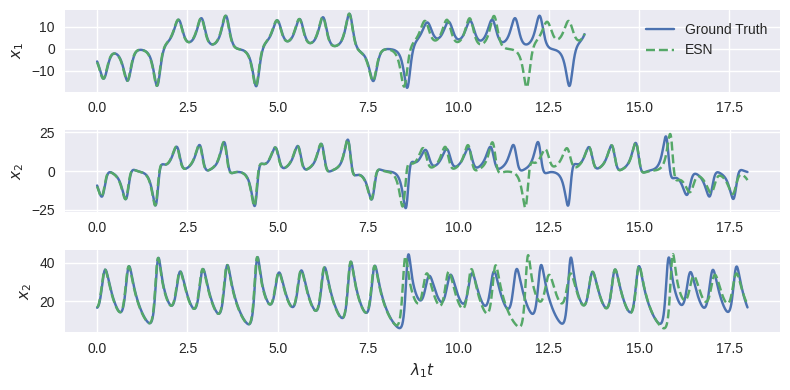

In [5]:
fig, ax = plt.subplots(3, figsize=((8,4)))

t = np.arange(0,2000) * 0.01 * 0.9


ax[0].plot(t[:1500], U.T[train_len:train_len+1500, 0], label='Ground Truth')
ax[0].plot(t[:1500], test_forecast[:1500,0], '--', label='ESN')
ax[0].set_ylabel('$x_1$')
ax[0].set_xlim([-0.9, 18.9])
ax[0].legend()

ax[1].plot(t, U.T[train_len:train_len+2000, 1])
ax[1].plot(t, test_forecast[:,1], '--')
ax[1].set_ylabel('$x_2$')

ax[2].plot(t, U.T[train_len:train_len+2000, 2])
ax[2].plot(t, test_forecast[:,2], '--')
ax[2].set_ylabel('$x_2$')
ax[2].set_xlabel('$\\lambda_1 t$')

plt.tight_layout()
plt.show()

### Timing performance

We evaluate timing for fixed forecast length with varying numbers of forecasts and varying forecast length from a single initial condition.

In [6]:
fcast_len = 500
num_fcasts = [1, 2, 5, 10, 20, 100, 200, 500, 1000]
par_list = []

batch_forecast = eqx.filter_jit(eqx.filter_vmap(esn.forecast))

for ii in range(len(num_fcasts)):
    # Run once to compile
    out = jax.block_until_ready(batch_forecast(output_seq[-num_fcasts[ii]:], fcast_len))

    t1 = time.time()
    out = jax.block_until_ready(batch_forecast(output_seq[-num_fcasts[ii]:], fcast_len))
    t2 = time.time()
    par_list.append(t2 - t1)


Text(0, 0.5, 'Time')

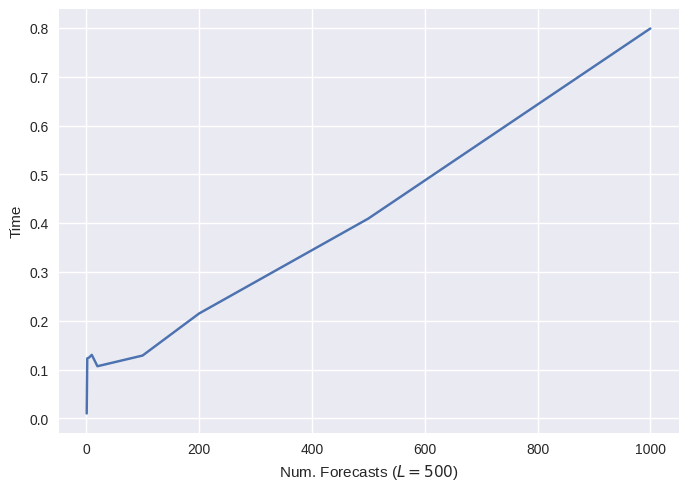

In [7]:
plt.plot(num_fcasts, par_list)
plt.xlabel("Num. Forecasts ($L=500$)")
plt.ylabel("Time")

In [8]:
fcast_len = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
num_fcasts = [1, 10, 200, 1000]
t_list = []
tot_list = []

batch_forecast = eqx.filter_jit(eqx.filter_vmap(esn.forecast))
for jj in range(len(num_fcasts)):
    t_list = []
    for ii in range(len(fcast_len)):
        # Run once to compile
        out = jax.block_until_ready(batch_forecast(output_seq[-num_fcasts[jj]:], fcast_len[ii]))

        t1 = time.time()
        out = jax.block_until_ready(batch_forecast(output_seq[-num_fcasts[jj]:], fcast_len[ii]))
        t2 = time.time()
        t_list.append(t2 - t1)
    
    tot_list.append(t_list)


In [9]:
tot_list = jnp.array(tot_list)

Reservoirpy implementation.

In [10]:
from reservoirpy.nodes import Reservoir, Ridge
import time

reservoir = Reservoir(units=2000, lr=0.6, sr=0.8)
readout = Ridge(output_dim=3, ridge=1e-8)
esn = reservoir >> readout
t1 = time.time()
esn.fit(np_input[:-1], np_input[1:], warmup=500)
t2 = time.time()
print("Reservoirpy training time: ")
print(t2 - t1)
warming_inputs = np_input[-500:]
warming_out = esn.run(warming_inputs, reset=True)
reservoirpy_times = []



for ii in range(len(fcast_len)):
    nb_generations = fcast_len[ii]
    X_gen = np.zeros((nb_generations,3))
    y = warming_out[-1]

    t1 = time.time()
    for t in range(nb_generations):
        y = esn(y)
        X_gen[t,:] = y
    t2 = time.time()
    reservoirpy_times.append(t2 - t1)
    

Running Model-0: 49999it [00:18, 2760.88it/s]?, ?it/s]
Running Model-0: 100%|██████████| 1/1 [00:21<00:00, 21.36s/it]
/home/jmpw1/miniforge3/envs/jaxrc/lib/python3.12/site-packages/reservoirpy/nodes/readouts/ridge.py:17: LinAlgWarning: Ill-conditioned matrix (rcond=2.37592e-17): result may not be accurate.
  return linalg.solve(XXT + ridge, YXT.T, assume_a="sym")


Fitting node Ridge-0...
Reservoirpy training time: 
21.930309534072876


Running Model-0: 500it [00:00, 2794.66it/s]           


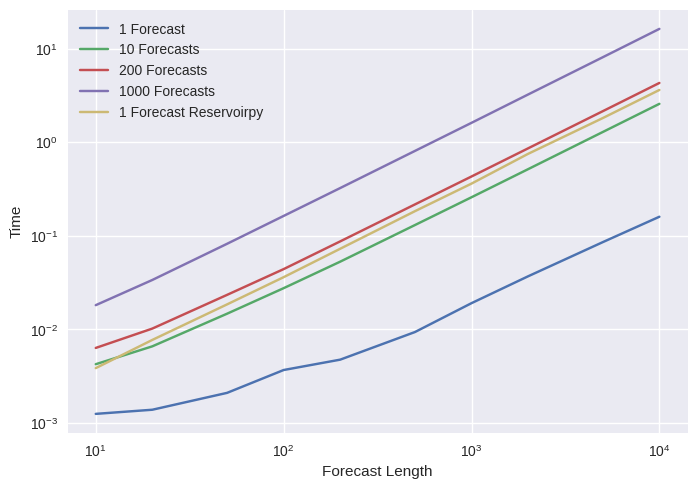

In [11]:
plt.loglog(fcast_len, tot_list[0], label="1 Forecast")
plt.loglog(fcast_len, tot_list[1], label="10 Forecasts")
plt.loglog(fcast_len, tot_list[2], label="200 Forecasts")
plt.loglog(fcast_len, tot_list[3], label="1000 Forecasts")
plt.loglog(fcast_len, reservoirpy_times, label="1 Forecast Reservoirpy")
plt.xlabel("Forecast Length")
plt.ylabel("Time")
plt.legend()
plt.show()